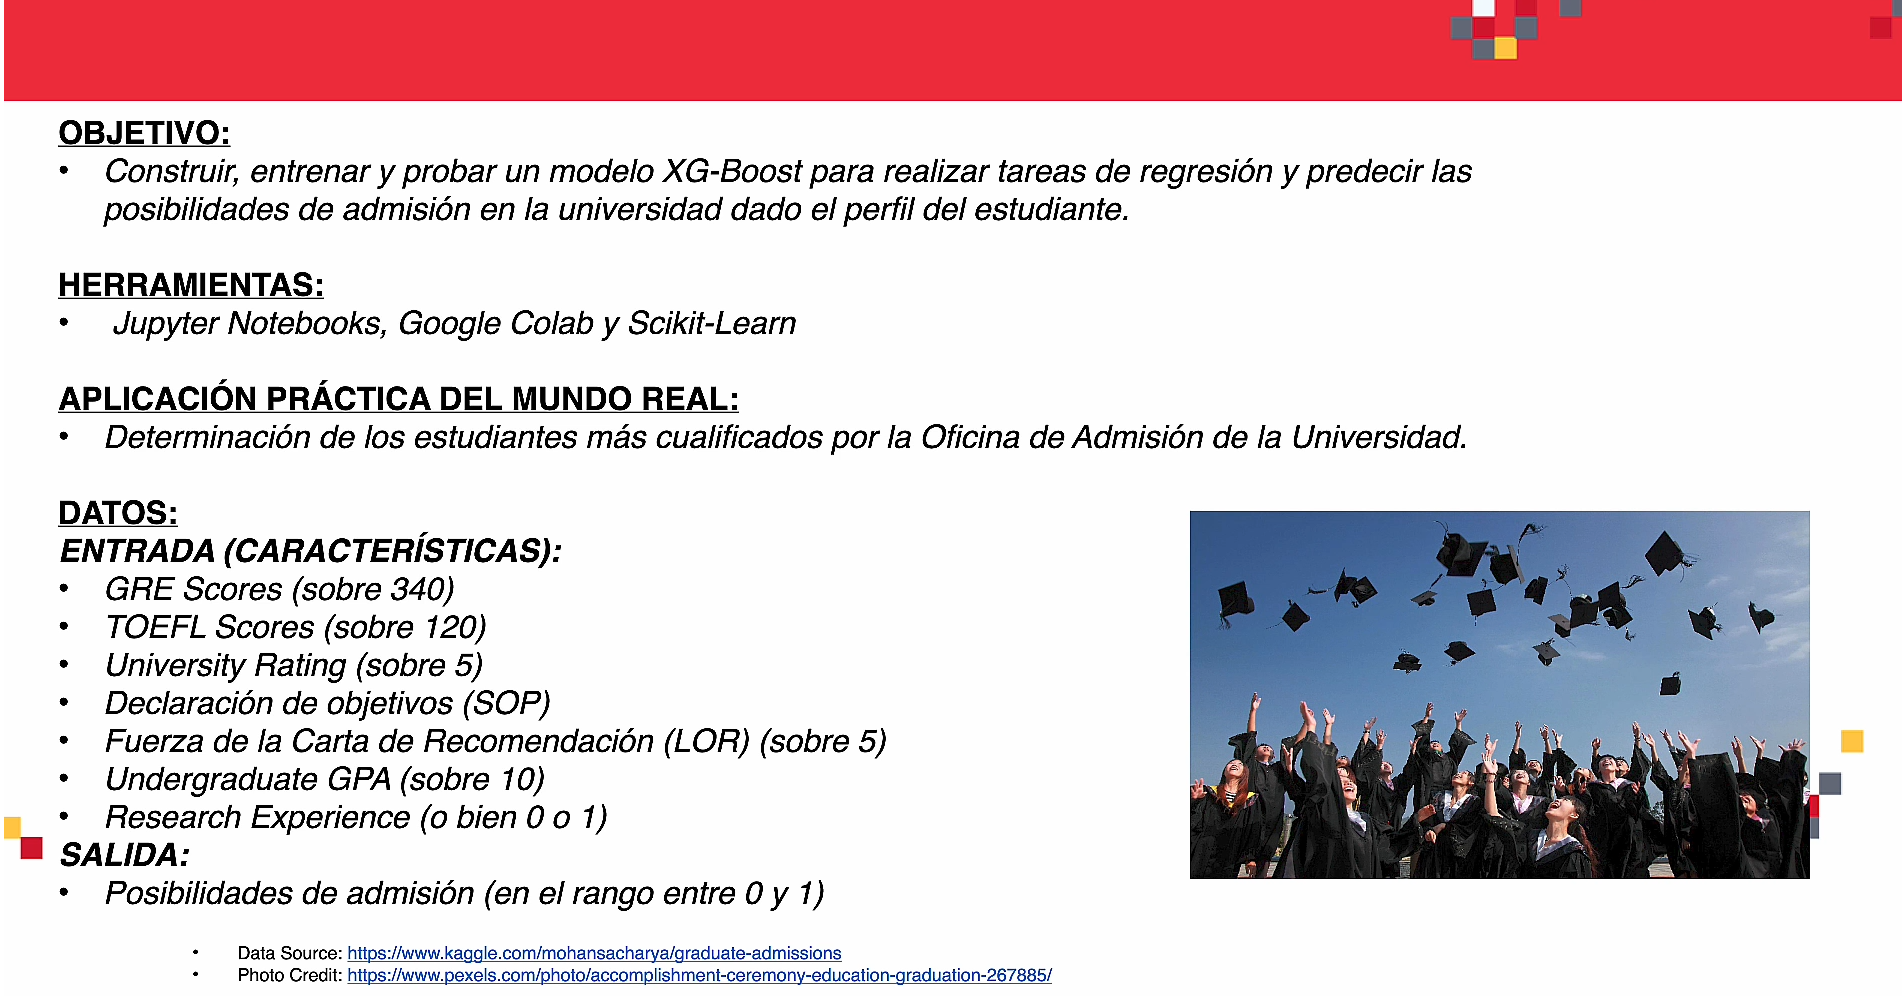

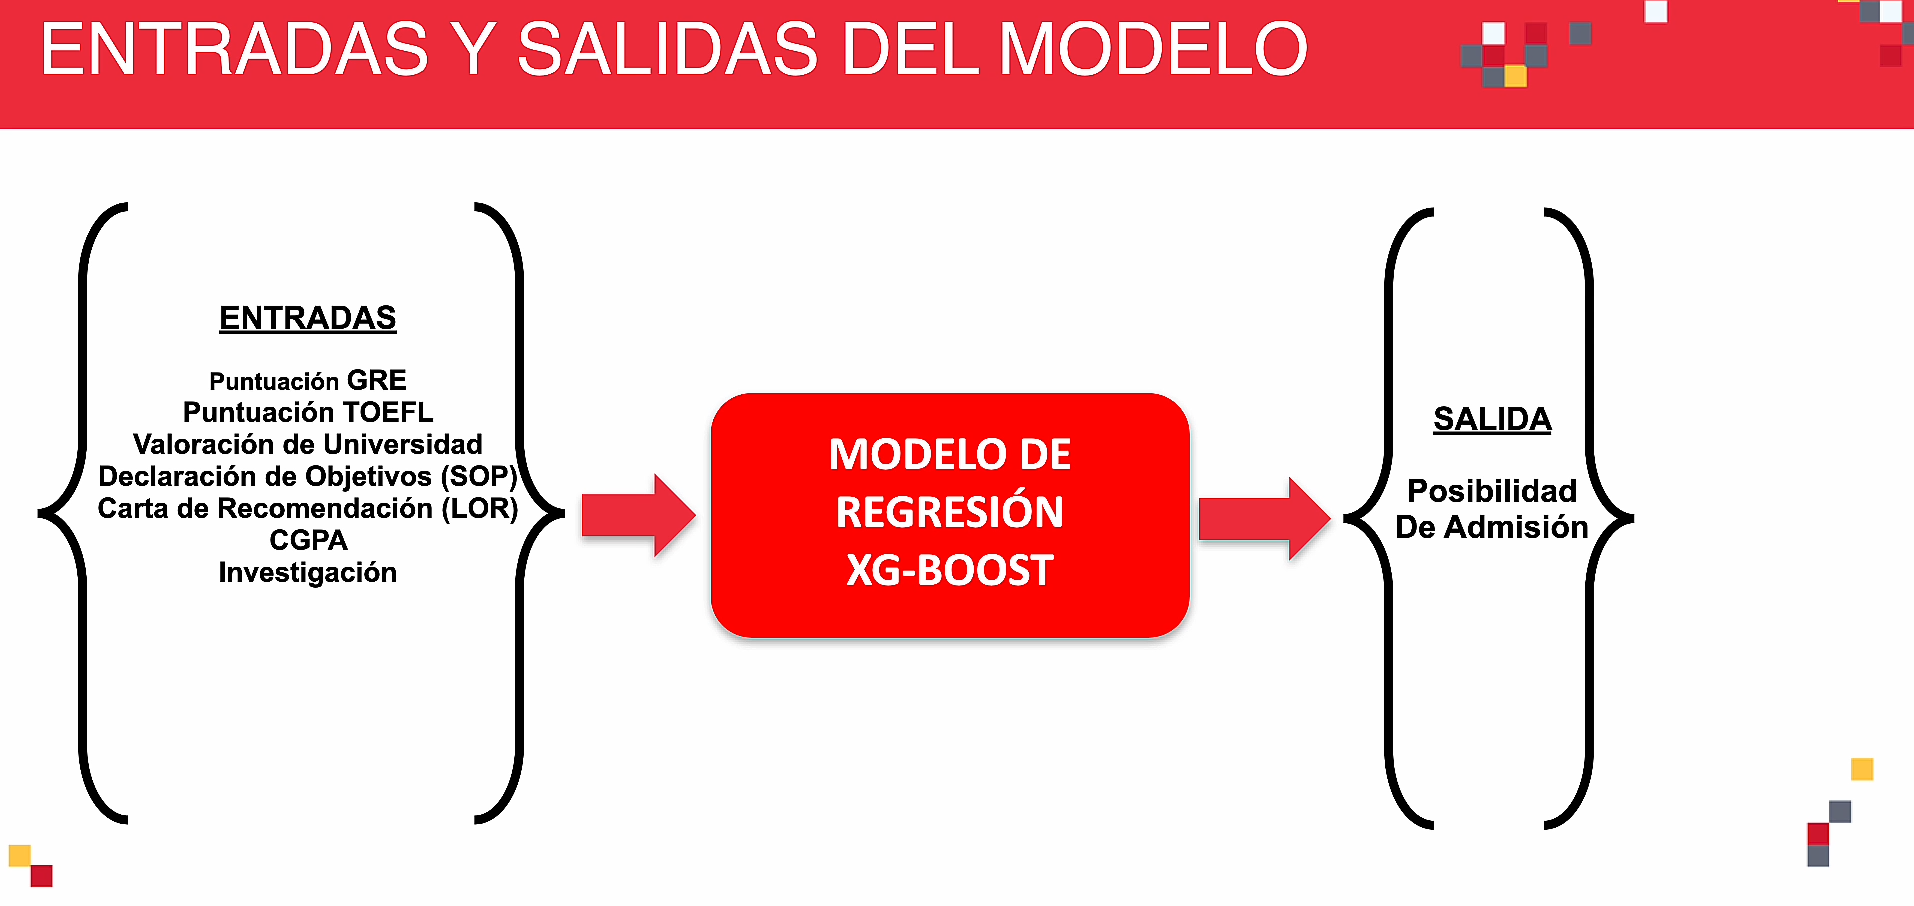

Objetivos de la actividad

Visualización de datos con las librerías Seaborn y Matplotlib
Entrenar un algoritmo eXtreem Gradient-boost para predecir la adminisón en la universidad.
Entregar un algoritmo XG-boost para predecir la esperanza de vida
Comprender la teoría/intuición detrás del boosting.
Ventajas y desventajas de XG-boost
Evaluar el rendimiento de los modelos entrenados

ANALISIS DE REGRESIÓN

In [ ]:
from google.colab import drive
drive.mount('/content/drive') #Debemos confirmar acceso a nuestra cuenta para el COLAB
#print(drive.mount)  #Imprime una direccion hexadecimal del apuntador a la carpeta drive
%cd "/content/drive/My Drive/Colab Notebooks/3DatosPractica"
%pwd
%ls

Mounted at /content/drive
/content/drive/My Drive/Colab Notebooks/3DatosPractica
Life_Expectancy_Data.csv  misdatos.csv  university_admission.csv


1: IMPORTAR LIBRERÍAS/DATASETS

In [ ]:
import seaborn as sb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Leer el fichero CSV
university_df = pd.read_csv("university_admission.csv")
salida = university_df
salida.to_csv("misdatos.csv")

In [ ]:
# Cargar las 6 primeras observaciones/datos
#Puntaje - TOEFL, Ranking de la Universidad, SOP Carta de intenciones, LOR Carta REcomendacion, CGPA, Investiga, Oportunidad de Seleccion
university_df.head(6)

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
5,330,115,5,4.5,3.0,9.34,1,0.90


In [ ]:
# Cargar las últimas 6 instancias
university_df.tail(6)

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
994,301,99,3,2.5,2.0,8.45,1,0.68
995,332,108,5,4.5,4.0,9.02,1,0.87
996,337,117,5,5.0,5.0,9.87,1,0.96
997,330,120,5,4.5,5.0,9.56,1,0.93
998,312,103,4,4.0,5.0,8.43,0,0.73
999,327,113,4,4.5,4.5,9.04,0,0.84


In [ ]:
# Mostrar las características / columnas
university_df.columns

Index(['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA',
       'Research', 'Chance_of_Admission'],
      dtype='object')

In [ ]:
# Comprobar la dimensión del dataframe
university_df.shape


(1000, 8)

In [ ]:
# Comprobar si hay valores faltantes en el dataframe o a hay algun dato nulo?
university_df.isnull().sum()

,0
GRE_Score,0
TOEFL_Score,0
University_Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance_of_Admission,0


In [ ]:
#Si hubiera datos faltantes, los eliminareos y trabajos con el nuevo data frame
university_df = university_df.dropna()

In [ ]:
#Cuales son los tipos de datos de nuestas columnas
university_df.dtypes

,0
GRE_Score,int64
TOEFL_Score,int64
University_Rating,int64
SOP,float64
LOR,float64
CGPA,float64
Research,int64
Chance_of_Admission,float64


OPORTUNIDAD PRÁCTICA #1 [OPCIONAL]:

¿Cuál es la puntuación TOEFL más alta, media y baja en este conjunto de datos?

In [ ]:
university_df.describe()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,316.472000,107.193000,3.114000,3.374000,3.484000,8.57644,0.560000,0.72174
std,11.289494,6.079368,1.142939,0.990507,0.924986,0.60451,0.496635,0.14107
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.80000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.12750,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.56000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.04000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.92000,1.000000,0.97000


2: REALIZAR ANÁLISIS EXPLORATORIOS Y VISUALIZACIÓN DE DATOS Hagamos EDA

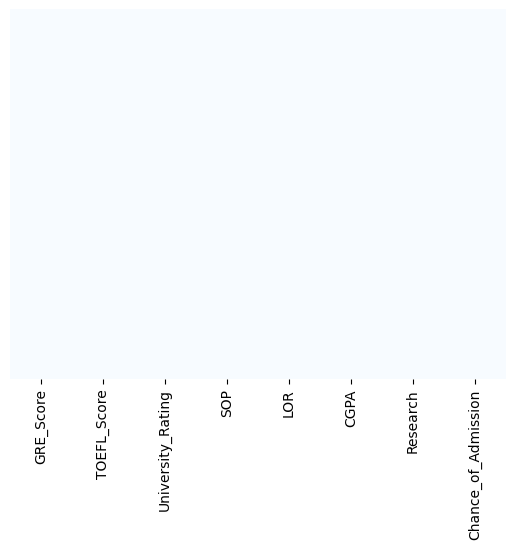

In [ ]:
# Comprobar si hay algún valor nulo
sb.heatmap(university_df.isnull(), yticklabels = False, cbar = False, cmap="Blues")
#yticklabels = False para que no aparezcan toodas las eqtiquetas
plt.show()
#No hay nada? Excelente, significa que no faltan datos nulos o faltantes

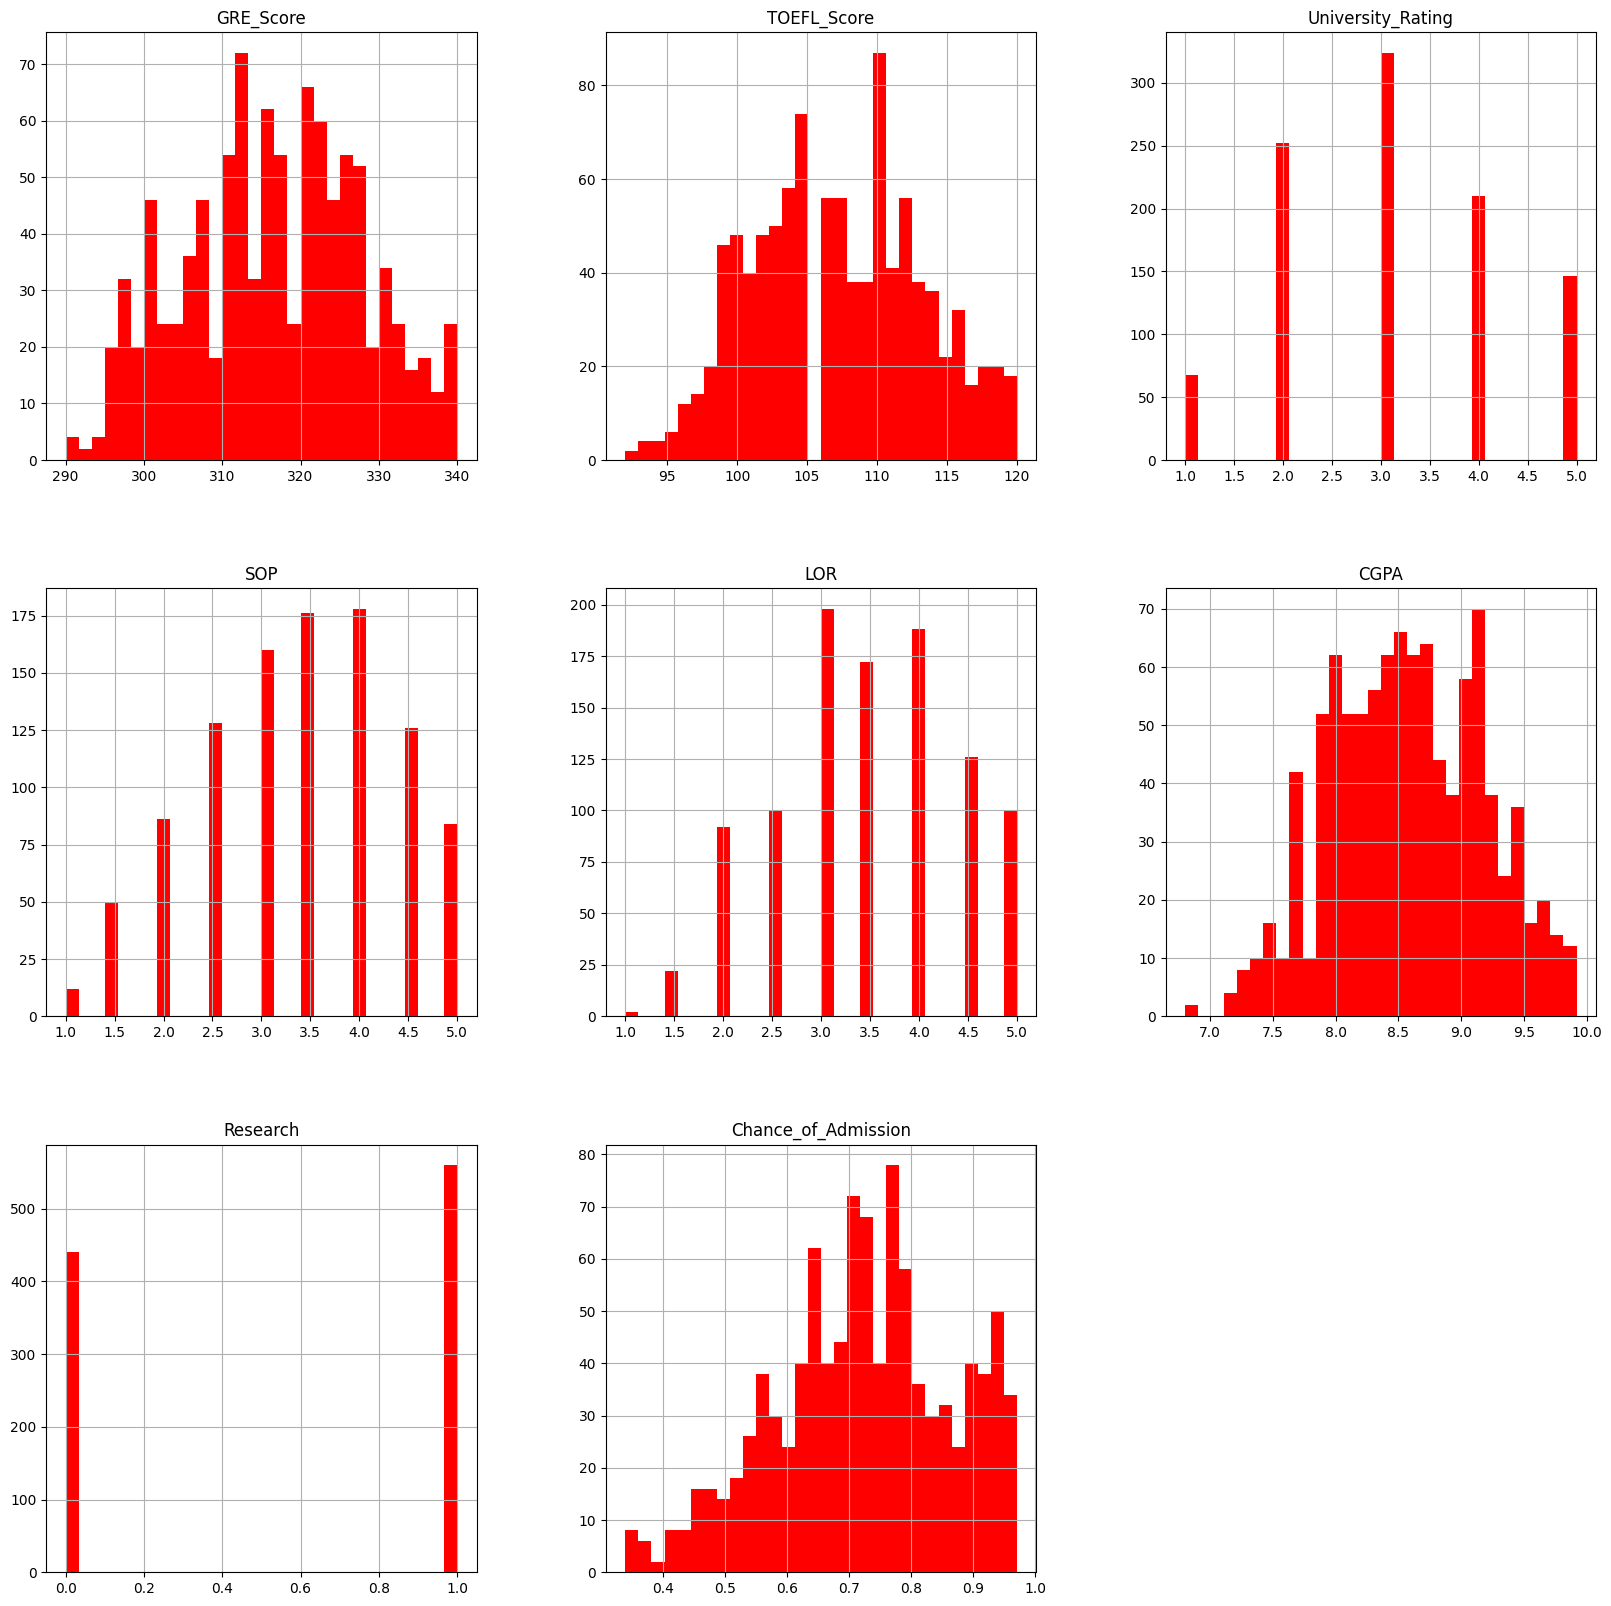

In [ ]:
university_df.hist(bins = 30, figsize = (20,20), color = 'r');
plt.show()

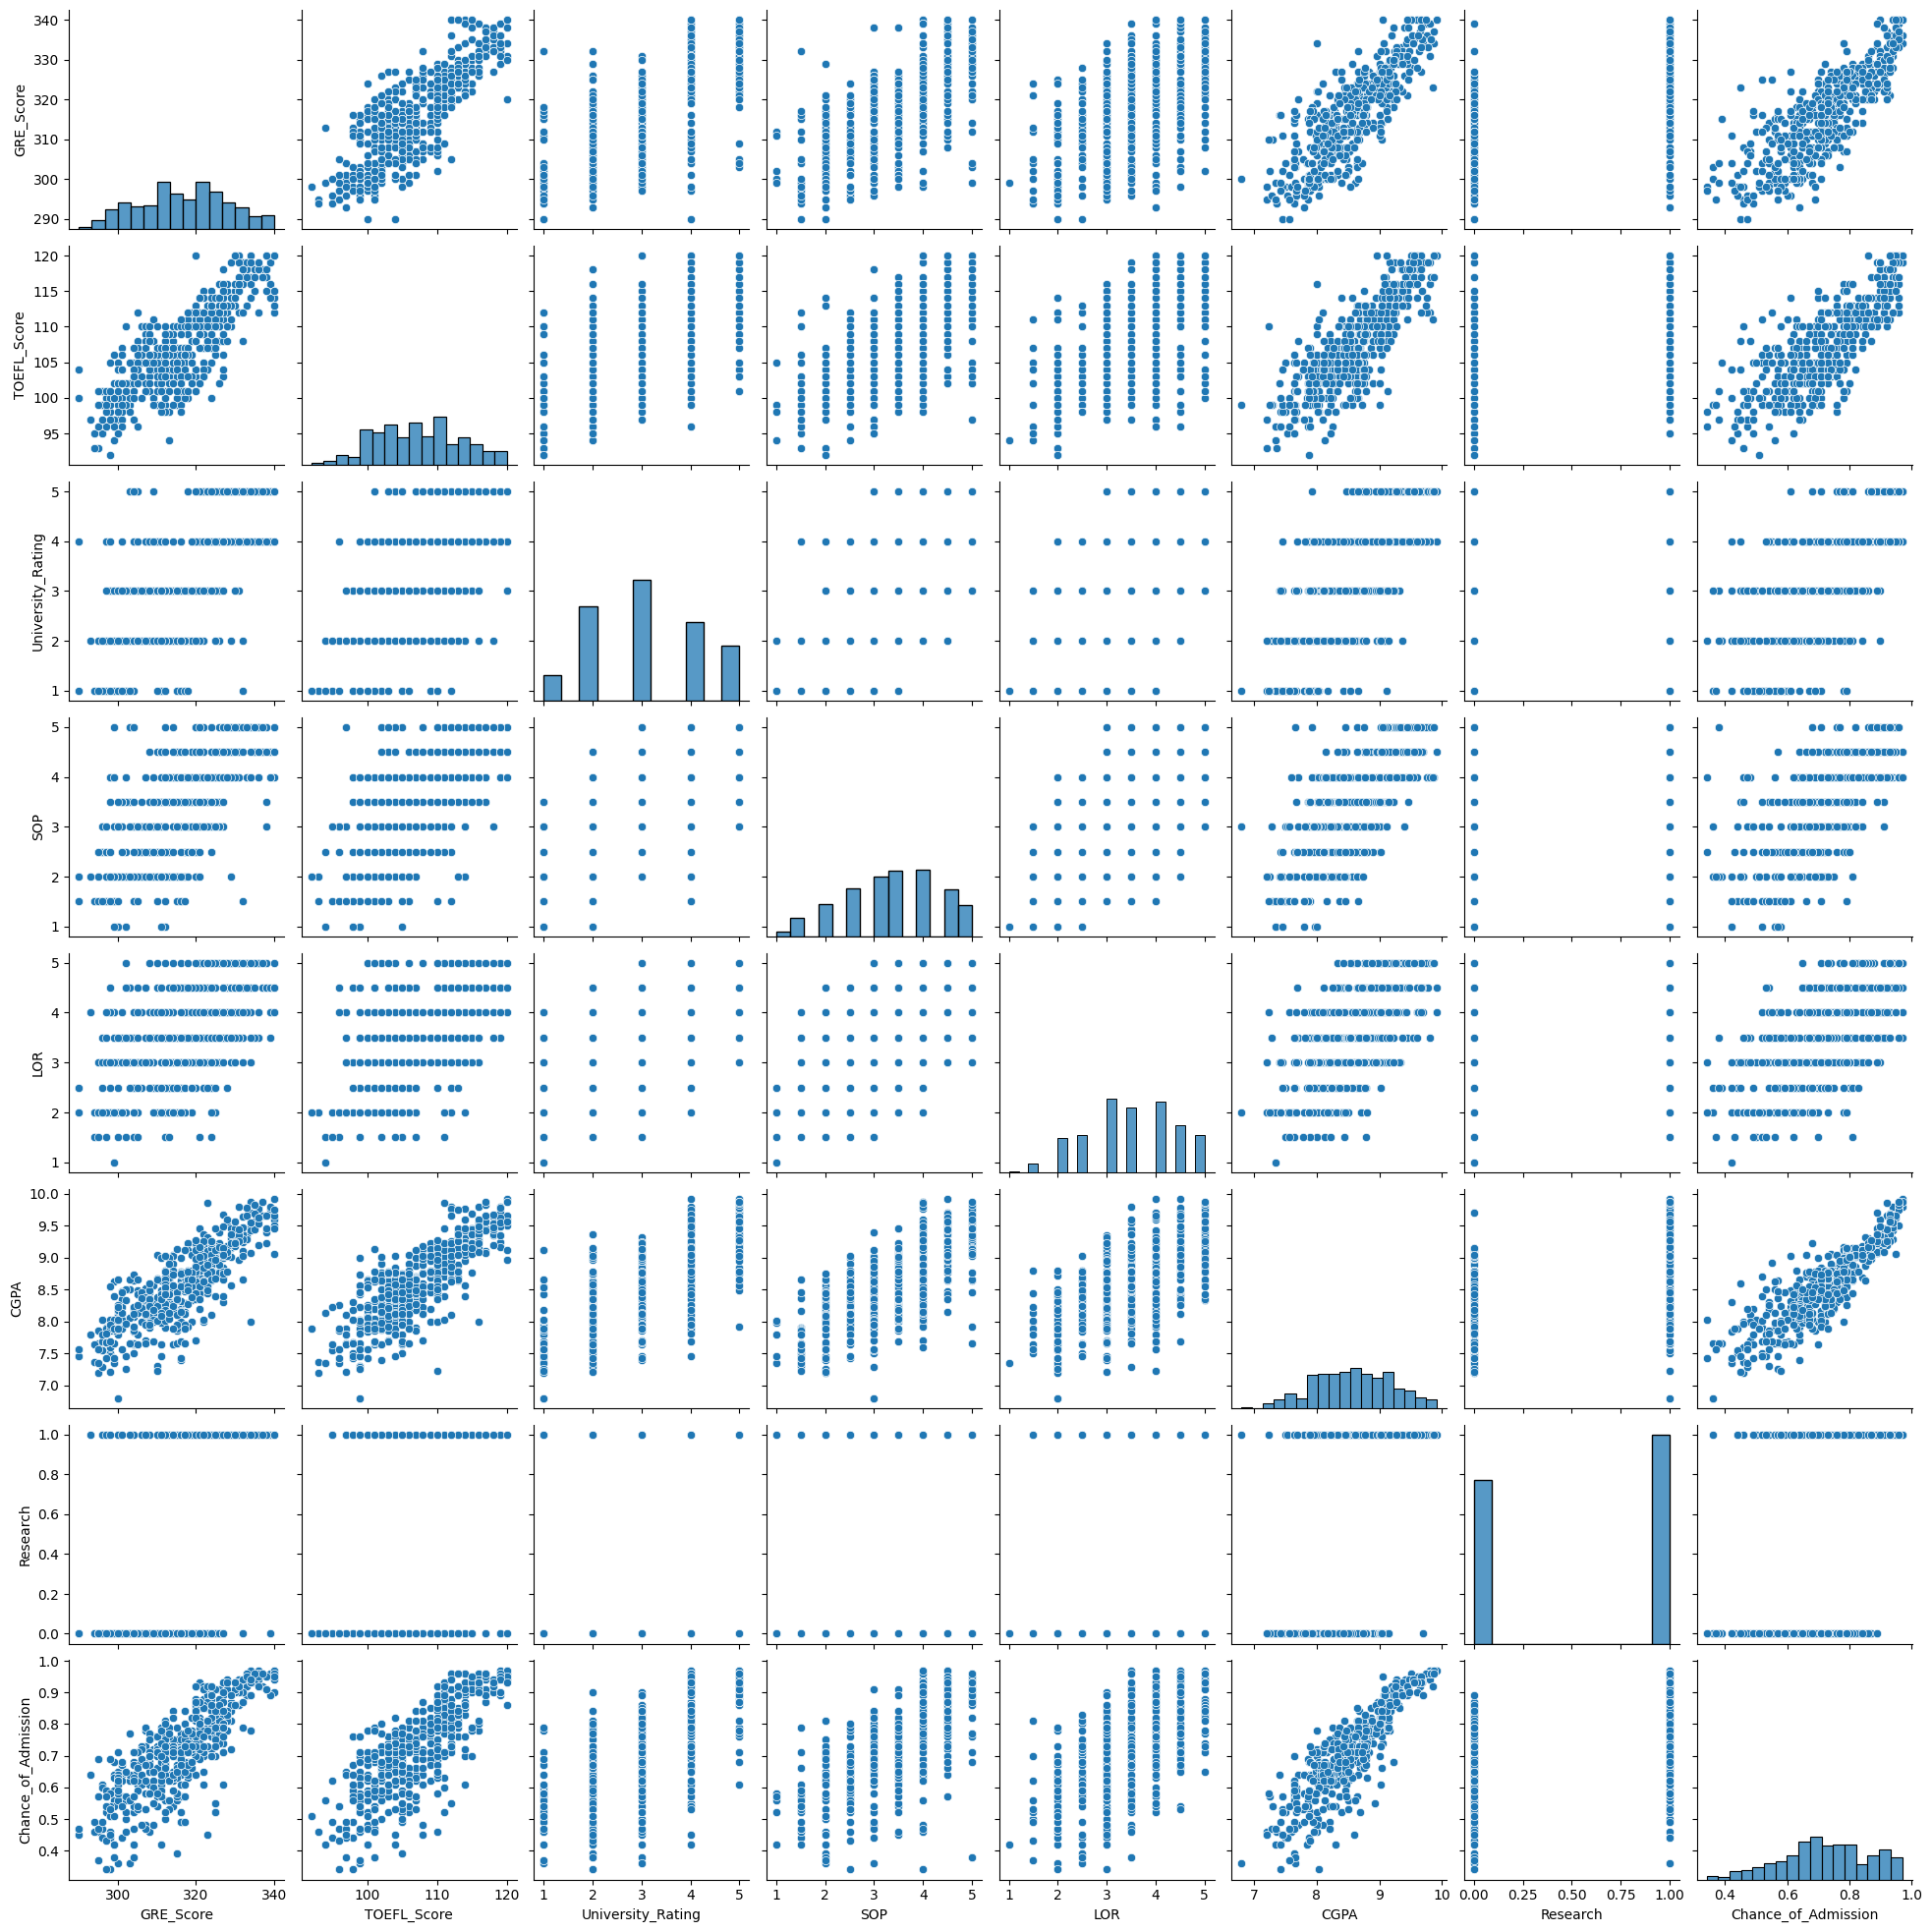

In [ ]:
sb.pairplot(university_df) #Diferentes graficos de dispersion entre todas las columnas y la distribucion de la columna
plt.show()

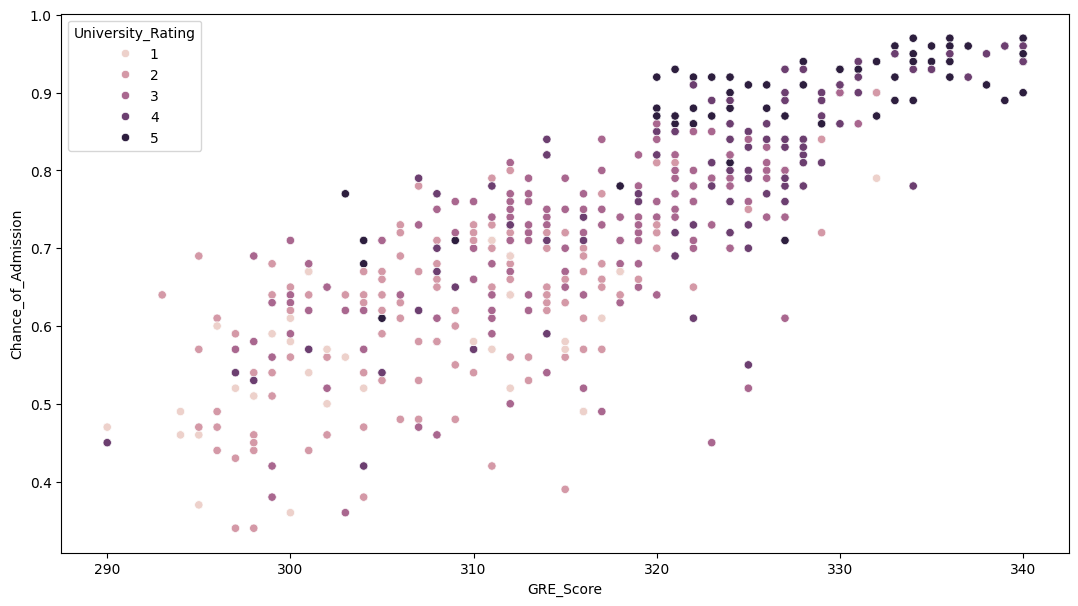

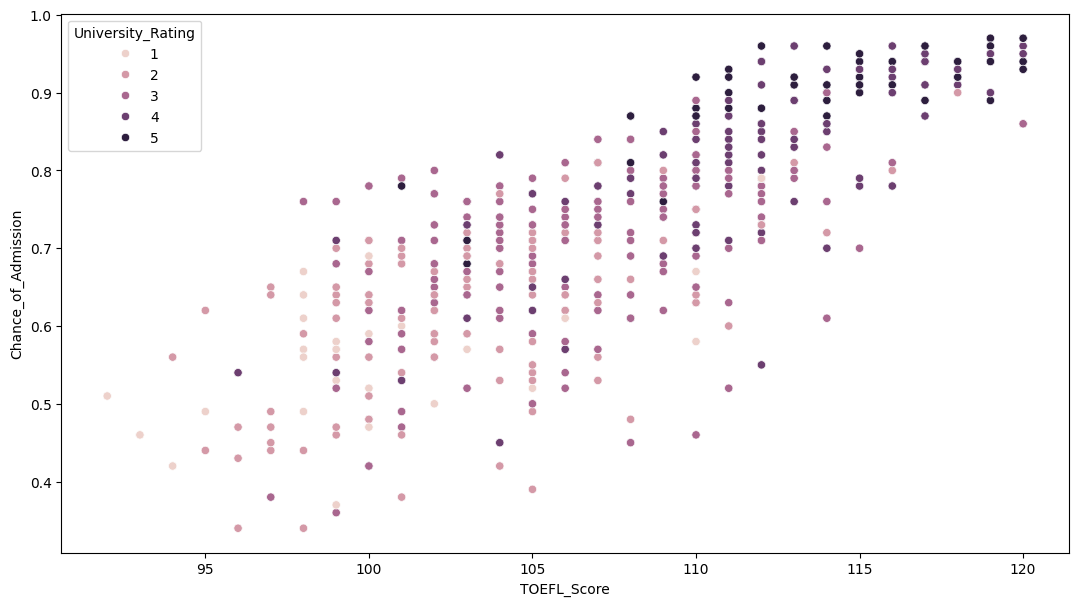

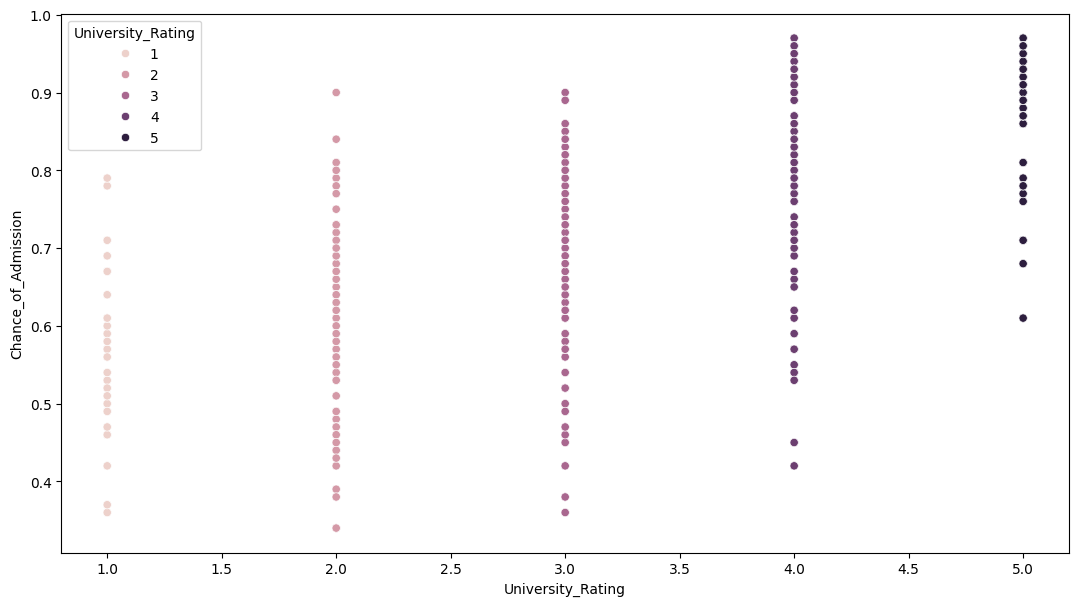

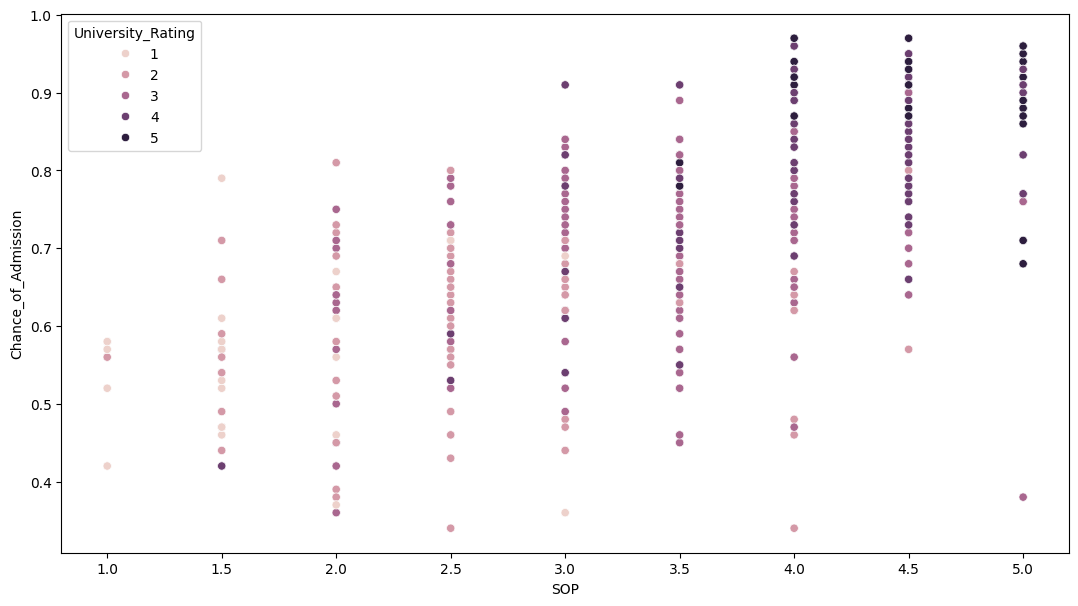

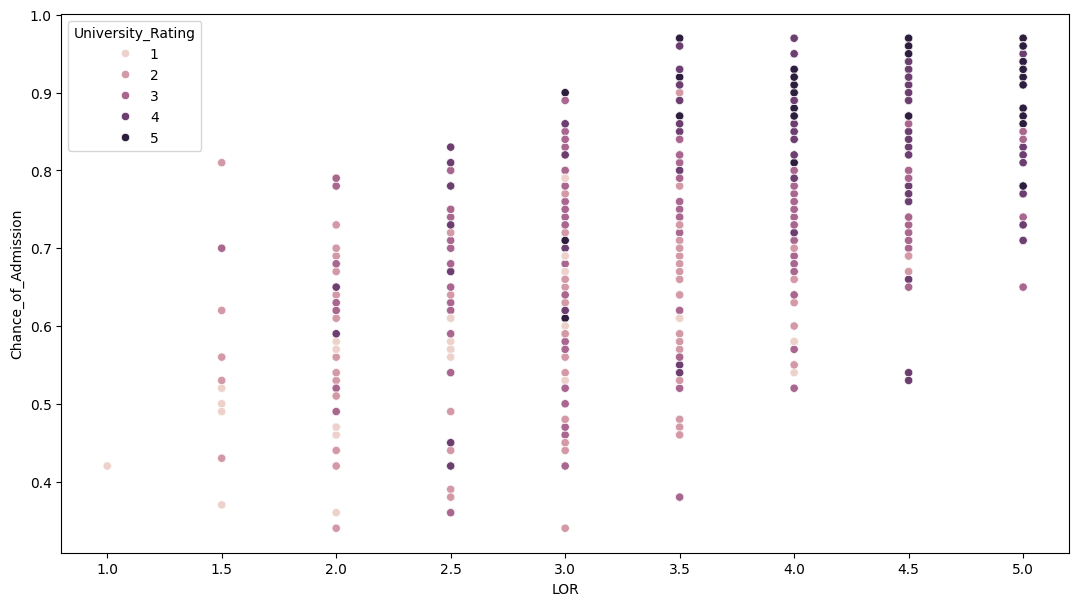

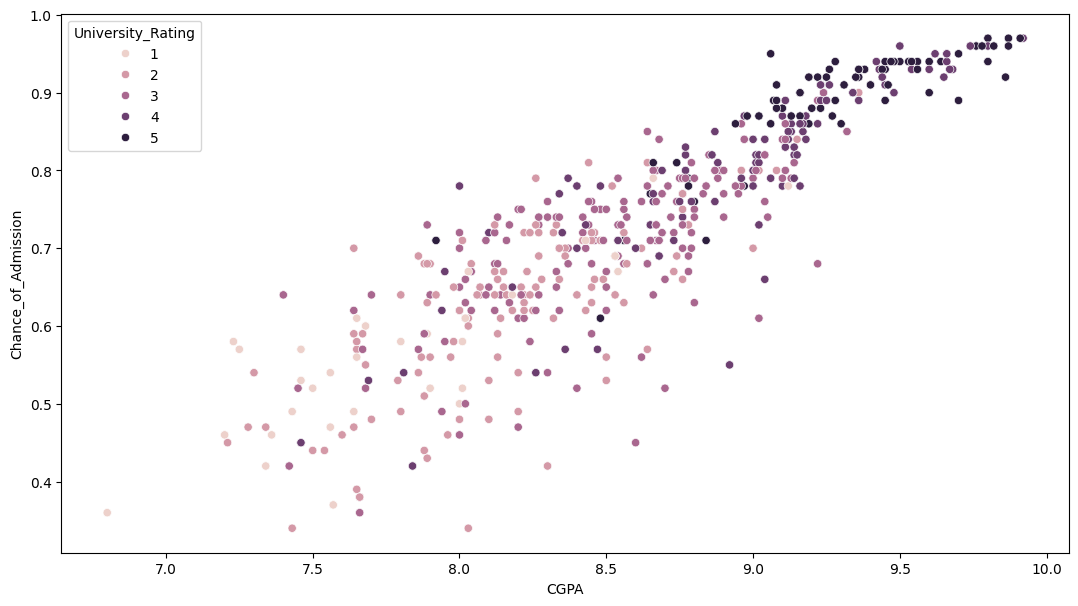

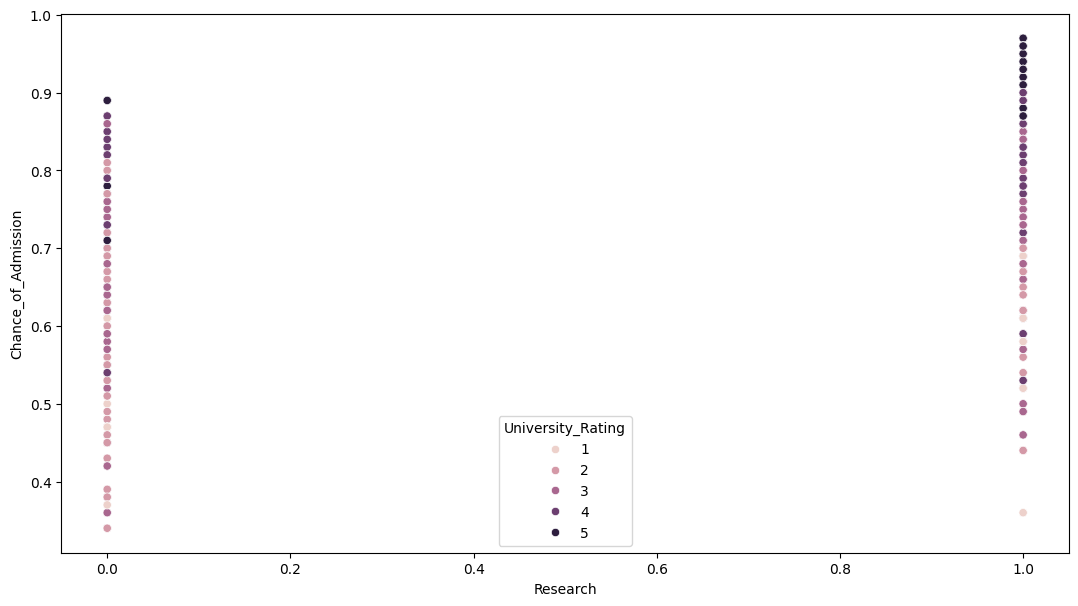

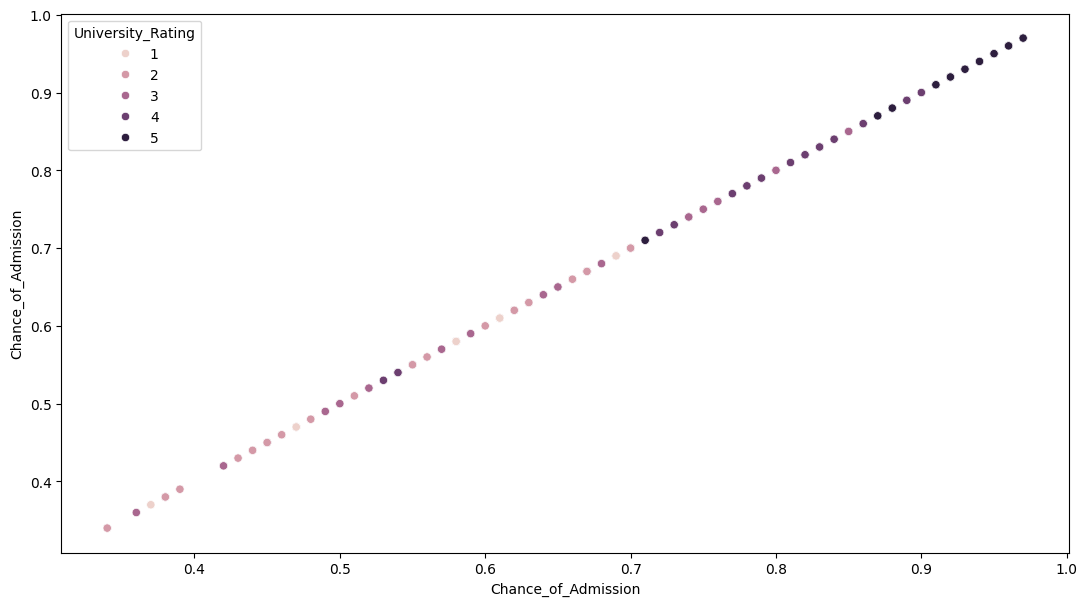

In [ ]:
for i in university_df.columns:
  plt.figure(figsize = (13, 7))
  sb.scatterplot(x = i, y = 'Chance_of_Admission', hue = "University_Rating", hue_norm = (1,5), data = university_df)
  plt.show()

OPORTUNIDAD PRÁCTICA #2 [OPCIONAL]:

Representa la matriz de correlaciones
Comentar la matriz de correlaciones

In [ ]:
university_df.corr()


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
GRE_Score,1.000000,0.827076,0.635376,0.613498,0.524679,0.825878,0.563398,0.810351
TOEFL_Score,0.827076,1.000000,0.649725,0.644374,0.541340,0.810644,0.466453,0.791921
University_Rating,0.635376,0.649725,1.000000,0.728024,0.608651,0.705254,0.427047,0.690132
SOP,0.613498,0.644374,0.728024,1.000000,0.663707,0.712154,0.408116,0.684137
LOR,0.524679,0.541340,0.608651,0.663707,1.000000,0.637469,0.372526,0.645365
CGPA,0.825878,0.810644,0.705254,0.712154,0.637469,1.000000,0.501311,0.882413
Research,0.563398,0.466453,0.427047,0.408116,0.372526,0.501311,1.000000,0.545871
Chance_of_Admission,0.810351,0.791921,0.690132,0.684137,0.645365,0.882413,0.545871,1.000000


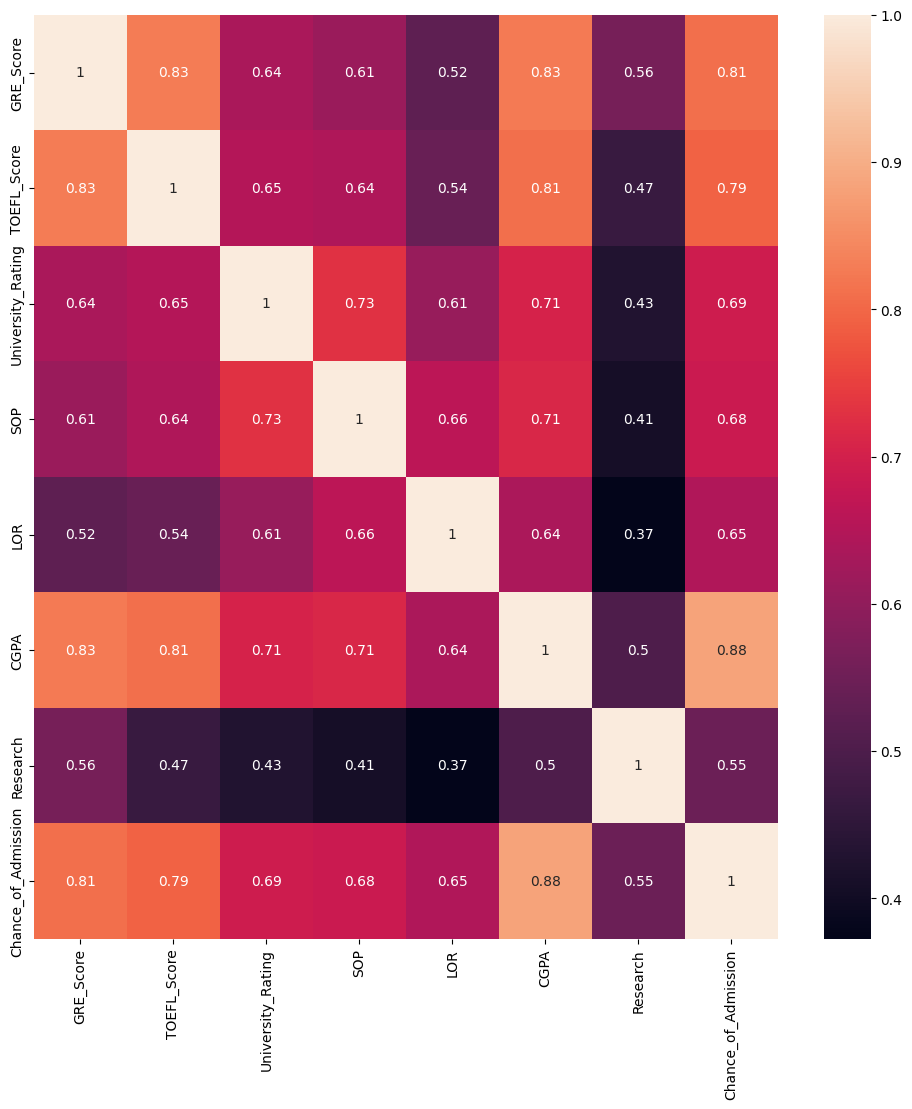

In [ ]:
matriz_correlacionada = university_df.corr()
plt.figure(figsize = (12, 12))
sb.heatmap(matriz_correlacionada, annot = True)
plt.show()

PREPARAR LOS DATOS ANTES DEL ENTRENAMIENTO DEL MODELO

In [ ]:
university_df.columns

Index(['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA',
       'Research', 'Chance_of_Admission'],
      dtype='object')

In [ ]:
X = university_df.drop(columns = ['Chance_of_Admission'])  #Elinemos  la columna, por que la ocupamos predecir (y)

In [ ]:
y = university_df['Chance_of_Admission'] #Nuestra variable objetivo

In [ ]:
X.shape

(1000, 7)

In [ ]:
y.shape


(1000,)

In [ ]:
X = np.array(X)
y = np.array(y)

In [ ]:
# Redimensionar el array de (1000,) a (1000, 1)
y = y.reshape(-1,1)
y.shape

(1000, 1)

In [ ]:
# Escalar los datos antes de entrenar el modelo; Este codigo realiza el escalado, pero XGbost no requiere escalr los datos, pero en redes
#   neuronales si o en otro tipo de datos

# from sklearn.preprocessing import StandardScaler, MinMaxScaler
# scaler_x = StandardScaler()
# X = scaler_x.fit_transform(X)
# scaler_y = StandardScaler()
# y = scaler_y.fit_transform(y)

OPORTUNIDAD PRÁCTICA Nº3 [OPCIONAL]:

Dividir los datos en un 25% de prueba y un 75% de entrenamiento.
Compruebar que la división se ha realizado correctamente obteniendo la dimensión de los conjuntos de datos de prueba y entrenamiento.
¿Por qué hemos comentado la celda de código de escalado de datos?

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

In [ ]:
X_train.shape

(750, 7)

In [ ]:
X_test.shape

(250, 7)

4: ENTRENAR Y EVALUAR UN ALGORITMO XG-BOOST

In [ ]:
!pip install xgboost #instalemos en COLAB, pero no siempre se requiere previamente

In [ ]:
# Entrenar un modelo de regresión con XGBoost

import xgboost as xgb

modelo = xgb.XGBRegressor(objective ='reg:squarederror', learning_rate = 0.1, max_depth = 2, n_estimators = 100) #Para resolver una regresión en este caso
#no de clasificacion. Por que hay mas opciones. Con el error al cuadratico. Requerimos especificar la tasa de aprendizaje, Los arboles que crearemos para
#la toma de decisiones. Crearemos 100 arboles de decisión.

modelo.fit(X_train, y_train) #ajustemos los datos

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
# Predecir la puntuación del modelo entrenado utilizando el conjunto de datos de prueba

result = modelo.score(X_test, y_test) #le damos una puntuacion segun el modelo de entrenamiento
print("Certeza : {}".format(result))

Certeza : 0.8748980187660438


In [ ]:
# Realizar predicciones en el conjunto de pruebas
y_predict = modelo.predict(X_test)


In [ ]:
y_predict #la preduiccion de cada estudiante a ser aceptado, el primer estudiante tiene 70%

array([0.6859508 , 0.7979653 , 0.41874623, 0.9093986 , 0.90617734,
       0.7103187 , 0.5581025 , 0.7221936 , 0.9445555 , 0.656216  ,
       0.47701958, 0.61090404, 0.7428323 , 0.6592521 , 0.6778407 ,
       0.66389525, 0.7675698 , 0.79510146, 0.842679  , 0.6546593 ,
       0.78158796, 0.6936654 , 0.66148406, 0.7770631 , 0.6389486 ,
       0.8565823 , 0.61808515, 0.942335  , 0.61703855, 0.6102845 ,
       0.8667494 , 0.71906847, 0.5645154 , 0.92143303, 0.52287024,
       0.6774064 , 0.6664529 , 0.74662924, 0.8542289 , 0.6454635 ,
       0.51372755, 0.61928403, 0.5518085 , 0.73308474, 0.55734843,
       0.53164923, 0.621633  , 0.56473494, 0.49558234, 0.9226847 ,
       0.79819214, 0.5458488 , 0.5890807 , 0.5890807 , 0.85805386,
       0.38645628, 0.73701507, 0.6470338 , 0.8468366 , 0.5713233 ,
       0.8007382 , 0.56083393, 0.84174955, 0.7684077 , 0.7327659 ,
       0.69022334, 0.9468661 , 0.86427027, 0.9448235 , 0.7988701 ,
       0.8372393 , 0.70590794, 0.5908178 , 0.67851317, 0.74438

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt

RMSE = float(format(np.sqrt(mean_squared_error(y_test, y_predict)),'.3f')) #3 decimales
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

print('RMSE =',RMSE, '\nMSE =',MSE, '\nMAE =',MAE, '\nR2 =', r2)

RMSE = 0.053 
MSE = 0.00280827246103357 
MAE = 0.03747917532920837 
R2 = 0.8748980187660438


OPORTUNIDAD PRÁCTICA #4 [OPCIONAL]:

Reentrenar el modelo con menor 'max_depth'
Comentar los resultados

In [ ]:
modelo = xgb.XGBRegressor(objective ='reg:squarederror', learning_rate = 0.1, max_depth = 6, n_estimators = 200)
modelo.fit(X_train, y_train) #ajustemos los datos
result = modelo.score(X_test, y_test) #le damos una puntuacion segun el modelo de entrenamiento
print("Certeza : {}".format(result))

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt
RMSE = float(format(np.sqrt(mean_squared_error(y_test, y_predict)),'.3f')) #3 decimales
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

print('RMSE =',RMSE, '\nMSE =',MSE, '\nMAE =',MAE, '\nR2 =', r2)

Certeza : 0.9647354677868463
RMSE = 0.053 
MSE = 0.00280827246103357 
MAE = 0.03747917532920837 
R2 = 0.8748980187660438


PROYECTO DE PRACTICA

En este proyecto práctico, entrenaremos un modelo de Regresión Lineal para predecir la esperanza de vida.
Estos datos se obtuvieron inicialmente de la Organización Mundial de la Salud (OMS) y del sitio web de las Naciones Unidas. Los datos contienen características como el año, el estado, la esperanza de vida, la mortalidad adulta, las muertes infantiles, el porcentaje de gasto, el alcohol, etc.

Importar el conjunto de datos "Life_Expectancy_Data.csv" utilizando Pandas

Comprueba si existen valores perdidos en los datos, realiza ingeniería de variables para eliminar o rellenar los valores perdidos

¿Cuál es el uso de memoria del DataFrame?

Enumera la esperanza de vida mínima, media y máxima

Representa el histograma, el diagrama de pares y el mapa de correlación para todas las características.

Representa el diagrama de dispersión entre "Composición de ingresos de los recursos" y "Esperanza de vida", utilizando "estado" como atributo de color. Comenta el gráfico

Representa el diagrama de dispersión entre "Escolarización" y "Esperanza de vida", utiliza "estado" como atributo de color. Comenta el gráfico de dispersión.

Divide los datos en un 80% para entrenamiento y un 20% para pruebas.

Entrena un algoritmo XG-boost.

Evalúa el rendimiento del modelo de regresión entrenado, ¿cuál es R2?
Representa gráficamente las predicciones del modelo entrenado frente al resultado real.

In [ ]:
esperanza_de_vida = pd.read_csv('Life_Expectancy_Data.csv')
esperanza_de_vida

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


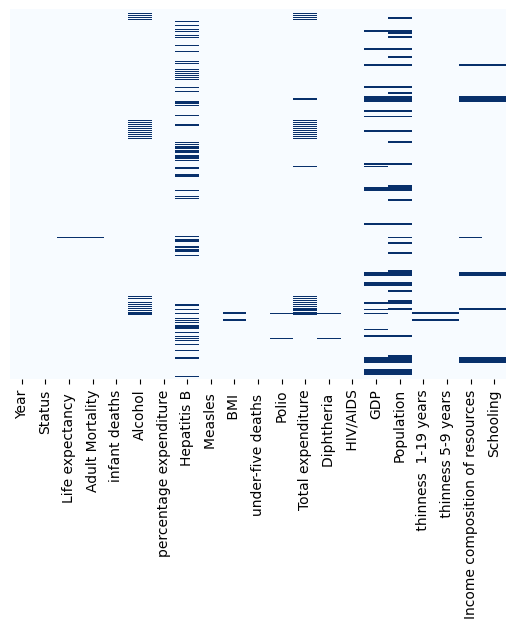

In [ ]:
sb.heatmap(esperanza_de_vida.isnull(), yticklabels=False, cbar=False, cmap='Blues')
plt.show()

In [ ]:
esperanza_de_vida.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             2938 non-null   int64  
 1   Status                           2938 non-null   object 
 2   Life expectancy                  2928 non-null   float64
 3   Adult Mortality                  2928 non-null   float64
 4   infant deaths                    2938 non-null   int64  
 5   Alcohol                          2744 non-null   float64
 6   percentage expenditure           2938 non-null   float64
 7   Hepatitis B                      2385 non-null   float64
 8   Measles                          2938 non-null   int64  
 9    BMI                             2904 non-null   float64
 10  under-five deaths                2938 non-null   int64  
 11  Polio                            2919 non-null   float64
 12  Total expenditure   

In [ ]:
esperanza_de_vida=esperanza_de_vida.select_dtypes(exclude=['object'])
esperanza_de_vida.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


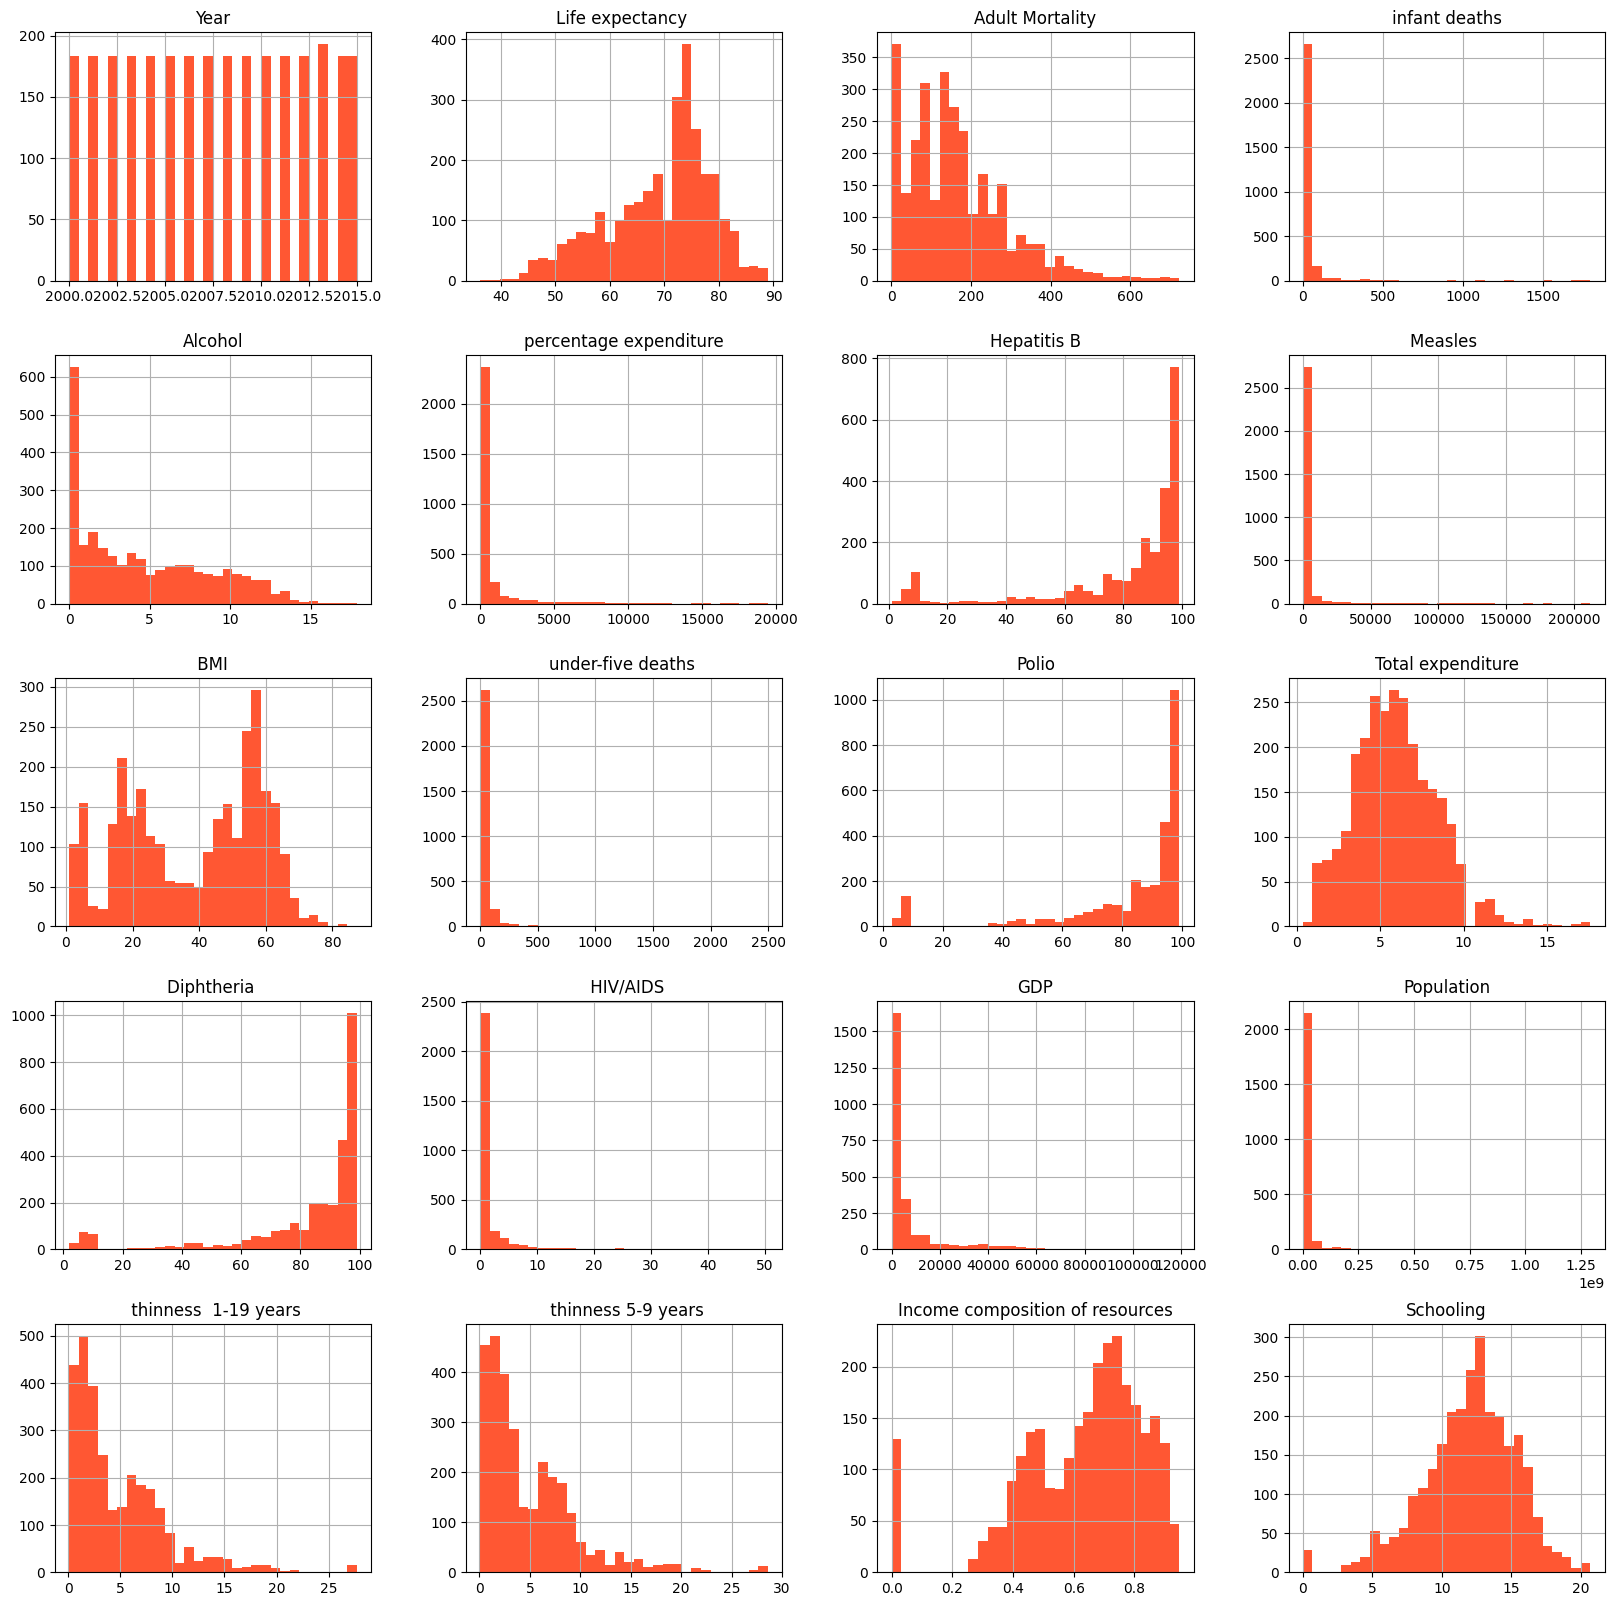

In [ ]:
esperanza_de_vida.hist(bins = 30, figsize = (20,20), color = '#ff5733');
plt.show()

In [ ]:
plt.figure(figsize = (20,20))
sb.pairplot(esperanza_de_vida)

Output hidden; open in https://colab.research.google.com to view.

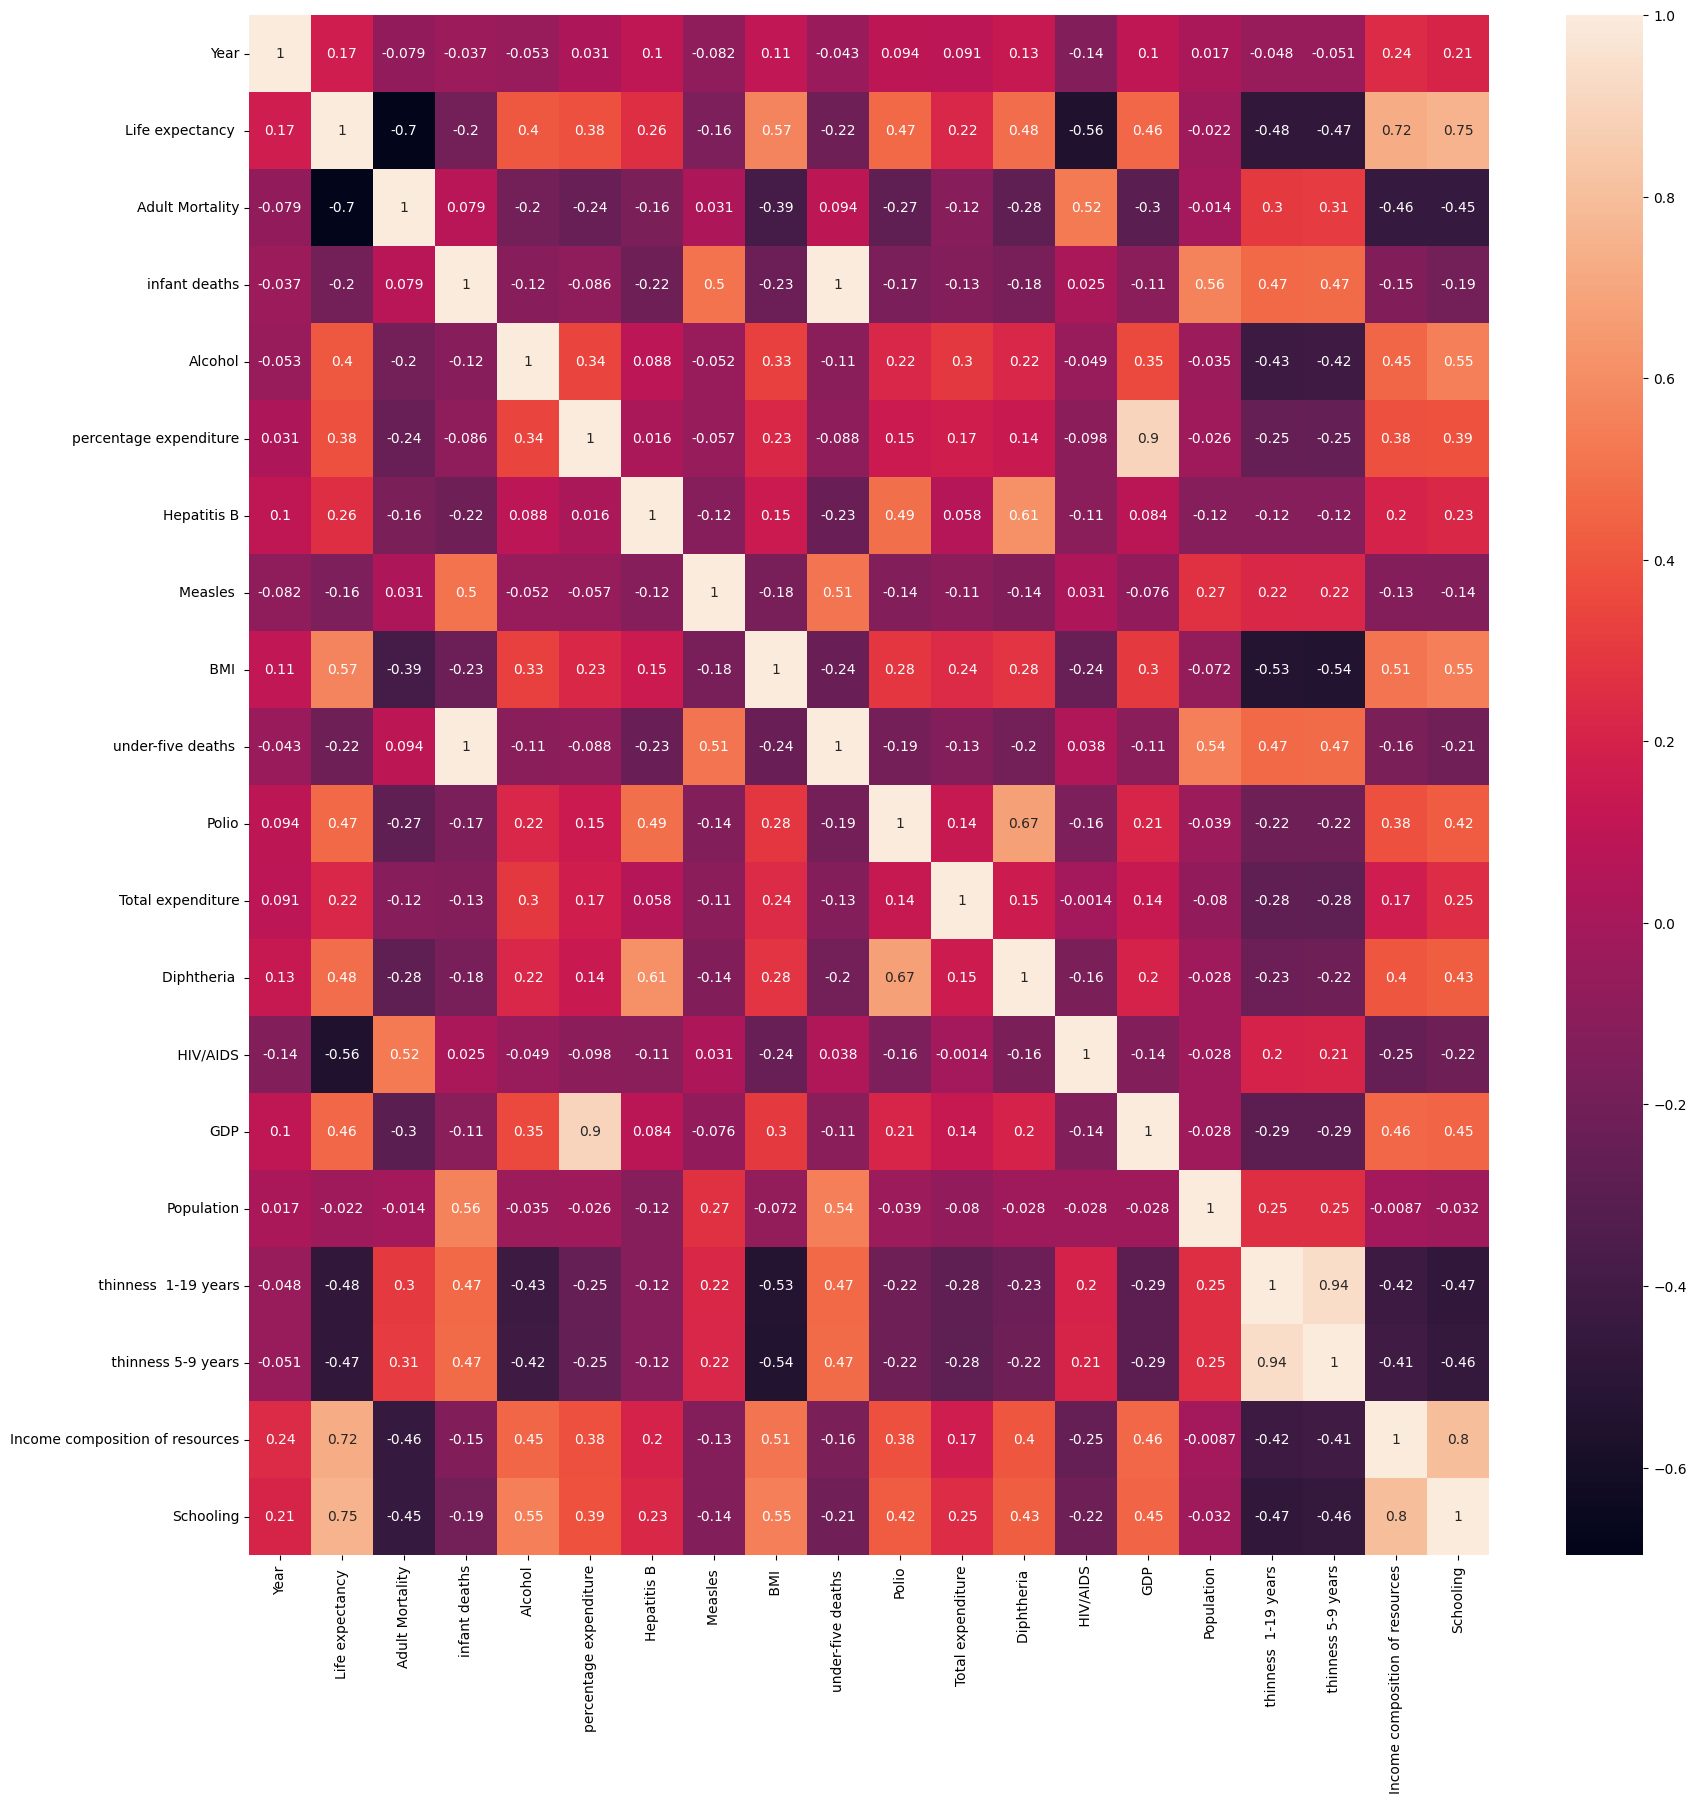

In [ ]:
plt.figure(figsize = (20,20))
matrix_correlacion = esperanza_de_vida.corr()
sb.heatmap(matrix_correlacion, annot = True)
plt.show()

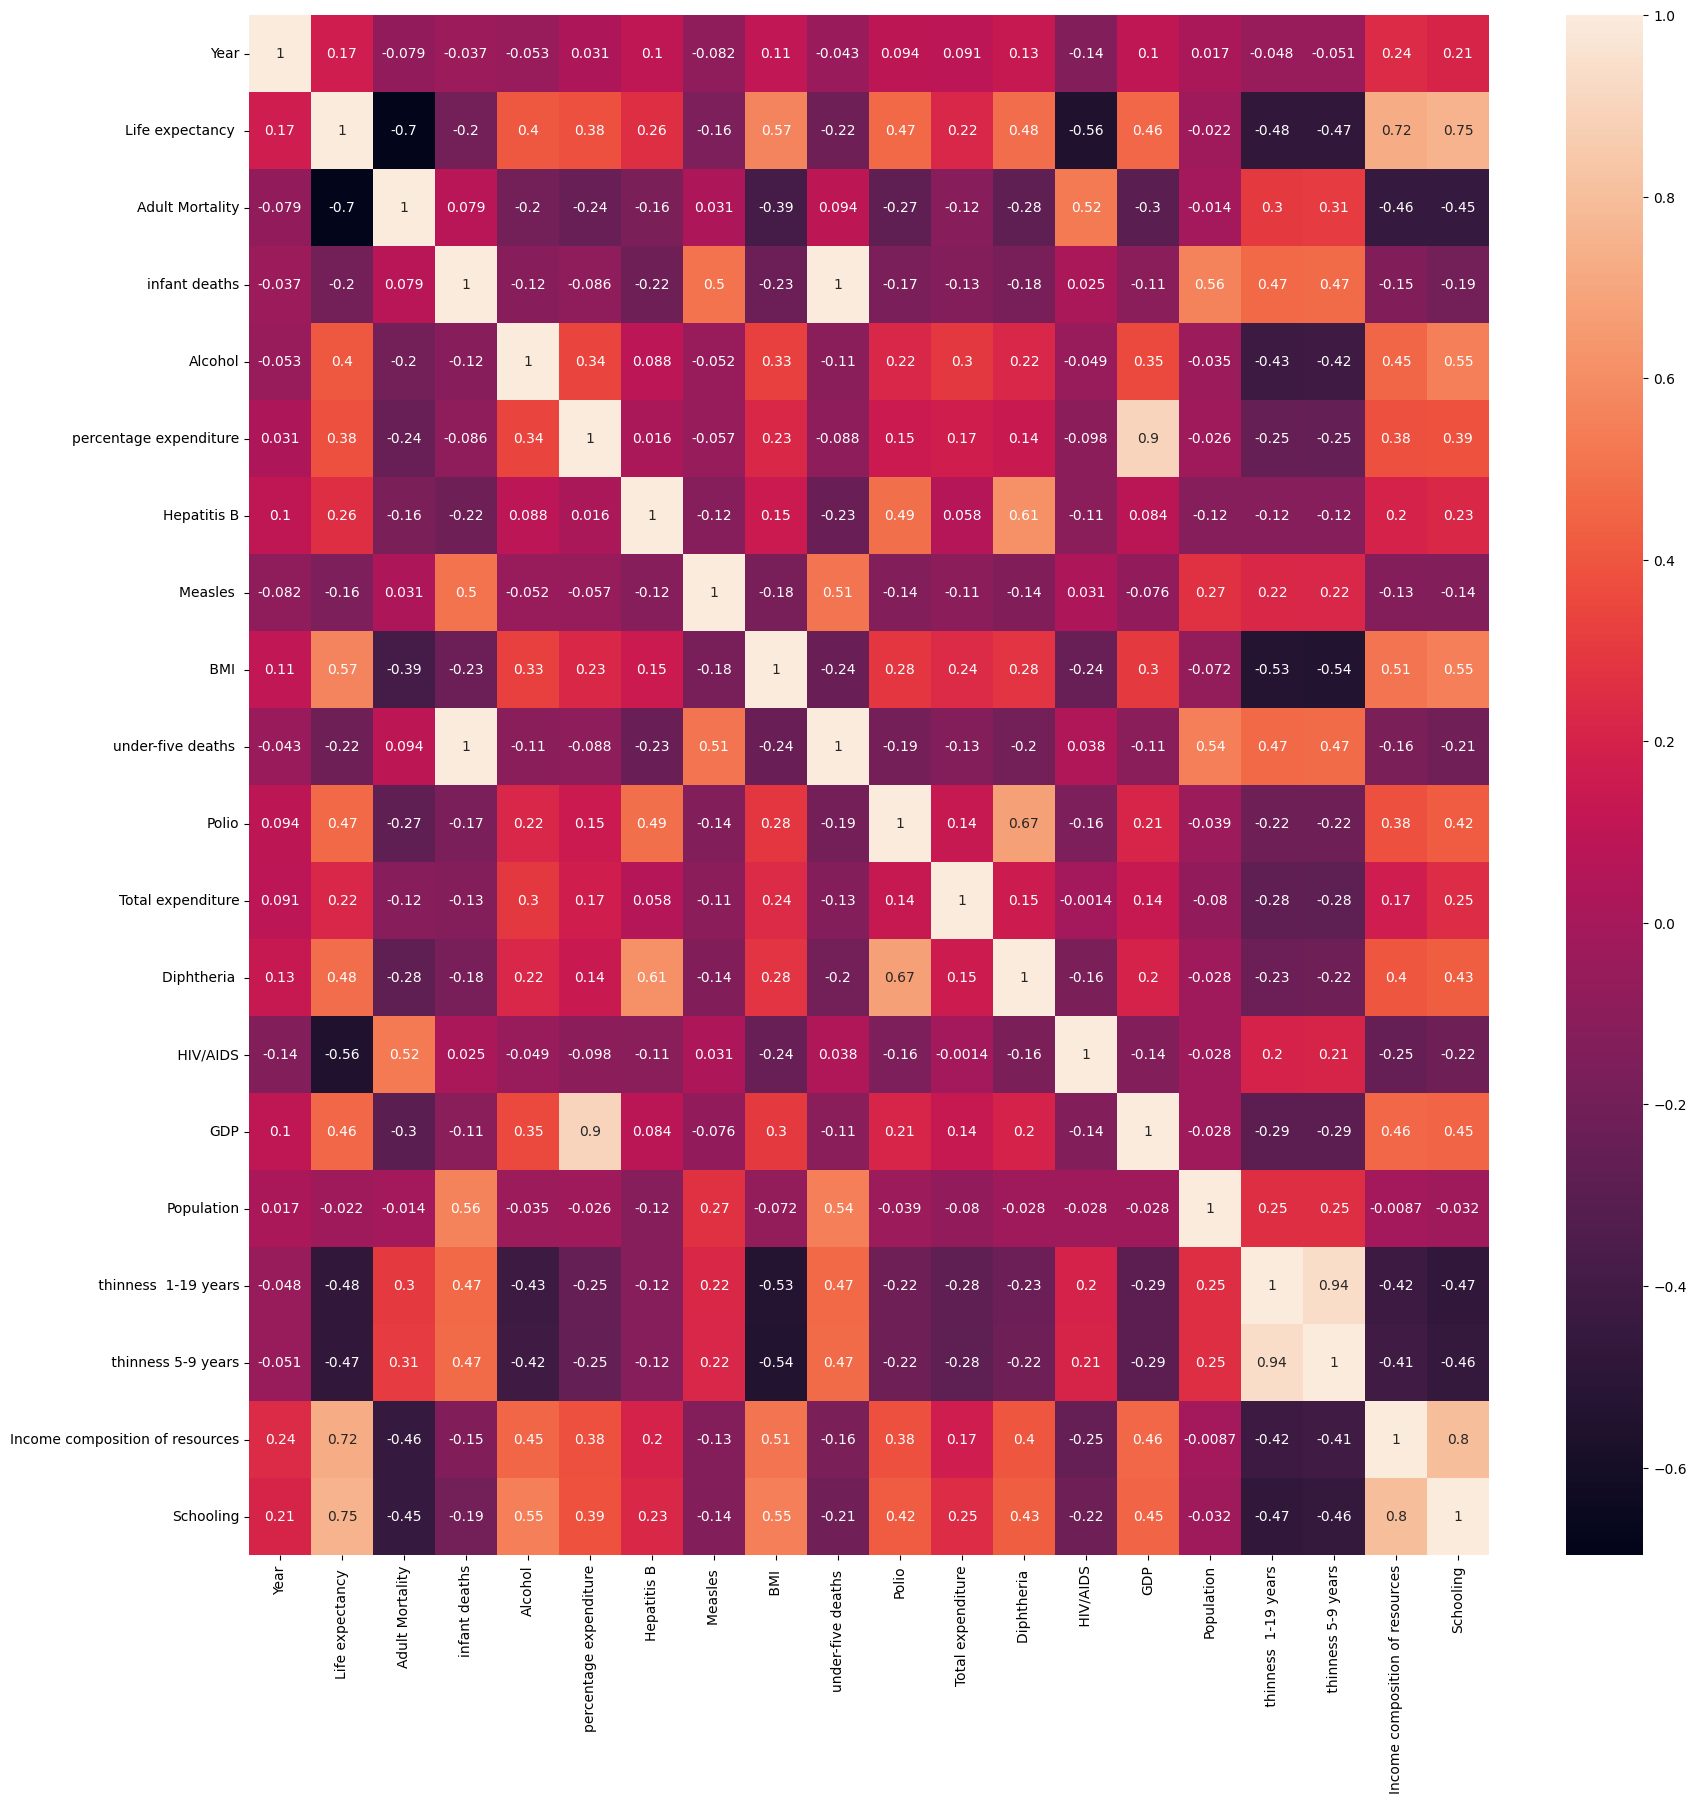

In [ ]:
plt.figure(figsize = (20,20))
matrix_correlacion = esperanza_de_vida.select_dtypes(include = ['float64', 'int']).corr()
sb.heatmap(matrix_correlacion, annot = True)
plt.show()

In [ ]:
esperanza_de_vida.isnull().sum()[np.where(esperanza_de_vida.isnull().sum() != 0)[0]]


<ipython-input-44-d19e51926ae8>:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  esperanza_de_vida.isnull().sum()[np.where(esperanza_de_vida.isnull().sum() != 0)[0]]


,0
Life expectancy,10
Adult Mortality,10
Alcohol,194
Hepatitis B,553
BMI,34
Polio,19
Total expenditure,226
Diphtheria,19
GDP,448
Population,652


In [ ]:
esperanza_de_vida.fillna(esperanza_de_vida.mean(), inplace = True)
esperanza_de_vida.isnull().sum()

,0
Year,0
Life expectancy,0
Adult Mortality,0
infant deaths,0
Alcohol,0
percentage expenditure,0
Hepatitis B,0
Measles,0
BMI,0
under-five deaths,0


In [ ]:
X = esperanza_de_vida.drop(columns = ['Life expectancy '])
y = esperanza_de_vida[['Life expectancy ']]

In [ ]:
print(X.shape, y.shape )


(2938, 19) (2938, 1)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [ ]:
from sklearn.metrics import mean_squared_error, accuracy_score

In [ ]:
import xgboost as xgb
modelo = xgb.XGBRegressor(objective ='reg:squarederror', learning_rate = 0.1, max_depth = 30, n_estimators = 100)
modelo.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=30, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
certeza_modelo = modelo.score(X_test, y_test)
print("Certeza : {}".format(certeza_modelo))

Certeza : 0.9607168436050415


In [ ]:
y_predict=modelo.predict(X_test)

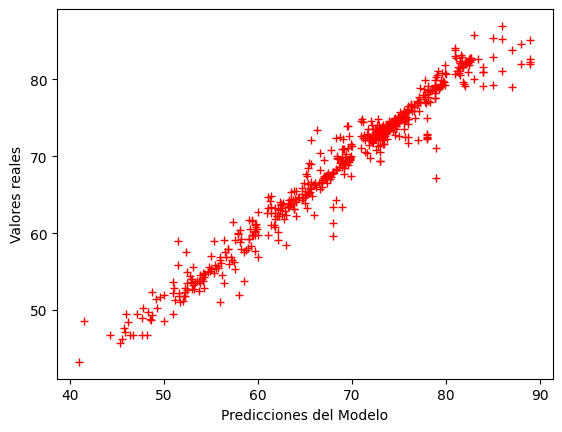

In [ ]:
plt.plot(y_test, y_predict, "+", color = "red")
plt.xlabel("Predicciones del Modelo")
plt.ylabel("Valores reales")
plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt
n = len(X_test)
k = X_test.shape[1]
print(k)
print("la cantidad de datos de pruebas es:", len(X_test))
print("la cantidad de datos de entrenamiento es:", len(X_train))
RMSE = float(format(np.sqrt(mean_squared_error(y_test, y_predict)),'.3f')) #3 decimales
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)
ajuste_r2 = 1 - (1-r2) * (n-1) / (n-k-1)
print('RMSE =',RMSE, '\nMSE =',MSE, '\nMAE =',MAE, '\nR2 =', r2, 'El valor ajustado de r2 = ', ajuste_r2)
#Un RMSE bajo indicara que el modelo tiene pocos errores y realiza buenas predicciones
#El R2 que es el coeficiente de determinacion mide la proporcion de la varianza en la variable dependiente
# R2 = 1 explica el 100% de la variacion de los datos, R2 = 0 no explica, y R2 negativo es peor que la predecir media


19
la cantidad de datos de pruebas es: 588
la cantidad de datos de entrenamiento es: 2350
RMSE = 1.937 
MSE = 3.7537821151542436 
MAE = 1.192134826725103 
R2 = 0.9607168436050415 El valor ajustado de r2 =  0.9594027943594355
